# Aula 4 — Coleta em redes sociais com Zeeschuimer

Nesta aula a gente sai um pouco do terminal e do Python puro e mexe direto no navegador: vamos instalar uma extensão **do Firefox** que observa o que uma plataforma social já carrega na sua tela enquanto você navega, e guarda isso de forma organizada, como dado estruturado. Depois abrimos o arquivo raspado, exploramos as variáveis, geramos nuvens de palavras, baixamos as imagens e os vídeos, e damos uma primeira olhada nas métricas. É o primeiro contato do curso com coleta em redes sociais, e por isso a aula começa pelos limites antes das ferramentas: o que pode ser coletado, o que não pode, e por quê.

## 1. O que o Zeeschuimer faz (e o que ele não faz)

**Zeeschuimer** é uma extensão de navegador criada pelo Digital Methods Initiative (Universidade de Amsterdã), pensada para pesquisa acadêmica sobre redes sociais. Ela não invade nada nem faz login automático em contas que não são suas: ela observa as respostas que a própria plataforma já envia para o seu navegador enquanto você rola o feed normalmente, logado com a sua conta, e salva essas respostas localmente, no seu computador.

Ou seja: se você já veria aquele post rolando o feed manualmente, o Zeeschuimer só está guardando isso de um jeito organizado, em vez de você copiar e colar na mão. Ele não coleta nada de perfis privados que você não teria acesso de outra forma, e não contorna nenhum bloqueio da plataforma.

## 2. Antes de instalar: os limites da coleta

CALMA antes de sair coletando qualquer coisa. Alguns pontos valem para toda coleta em redes sociais, não só hoje:

- **Termos de uso:** mesmo dado público (perfil aberto, hashtag, post visível pra qualquer pessoa) tem restrições de uso definidas pela plataforma. Coletar para estudo em aula é diferente de redistribuir ou usar comercialmente.
- **Rastros digitais:** atrás de cada post tem uma pessoa. Trate nomes de usuário, fotos, vídeos e textos coletados com o mesmo cuidado que gostaria que tivessem com os seus.
- **Escopo da coleta de hoje:** vamos fazer uma coleta pequena e demonstrativa, de um recorte público e combinado em aula (por exemplo, uma hashtag ou um perfil institucional aberto), só para aprender o fluxo de captura → exportação → exploração.

**ATENÇÃO:** não colete de perfis privados, não colete dados de menores de idade e não guarde nada além do que foi combinado em aula. Mais adiante vamos baixar imagens e vídeos: eles não devem ser redistribuídos, publicados ou usados fora do exercício. Se tiver qualquer dúvida se algo é apropriado de coletar, pare e pergunte antes.

## 3. Instalando o Firefox

O Zeeschuimer funciona de forma confiável no **Firefox**. Se seu navegador do dia a dia é outro (Chrome, Edge...), não precisa trocar: só instale o Firefox à parte, para usar especificamente com essa extensão.

Baixe em: https://www.mozilla.org/firefox/new/ ou na própria Microsoft Store (vamos ver se o computador da FGV permite)

**Windows:** execute o instalador baixado e siga as telas padrão, sem precisar mudar nada.

**Mac:** abra o arquivo `.dmg` baixado e arraste o ícone do Firefox para a pasta Aplicativos.

**OBS:** pode manter o seu navegador de sempre como está. O Firefox aqui é só a "casa" da extensão de hoje.

## 4. Instalando o Zeeschuimer

Com o Firefox aberto:

1. Acesse a página oficial da extensão: https://github.com/digitalmethodsinitiative/zeeschuimer/releases
2. Clique na mais recente (hoje é a v1.14.1) e clique em *Assets*
3. Escolha o arquivo com final .xpi
4. Clique em **Add to Firefox** (ou "Adicionar ao Firefox").
5. Confirme a permissão que o Firefox pedir.
6. Confira se o ícone do Zeeschuimer apareceu na barra de extensões, no canto superior direito.

**OBS:** se o ícone não aparecer sozinho na barra, clique no ícone de peça de quebra-cabeça (extensões) ao lado da barra de endereço e fixe o Zeeschuimer, para ele ficar sempre visível.

Documentação e código do projeto, caso queira entender melhor a ferramenta: https://github.com/digitalmethodsinitiative/zeeschuimer

## 5. Coletando: só navegue normalmente

Com a extensão instalada:

1. Abra, no mesmo Firefox, o Tiktok (o Zeeschuimer raspa várias redes, como Instagram, TikTok ou X, ou até mesmo o Linkedin).
2. Vá até o recorte escolhido (uma hashtag, um perfil público, uma busca).
3. Volte para o Zeeschuimer, aperte o Off da rede escolhida para que ele vire On. 
4. Volte para o Tiktok, e role o feed como você faria normalmente.
5. Clique no ícone do Zeeschuimer de vez em quando para conferir o contador de itens capturados subindo.

Não precisa clicar em nada especial durante a rolagem: a extensão intercepta o que a plataforma carrega em segundo plano, sozinha. Colete só o volume combinado (em torno de 100-250)

## 6. Exportando o que foi coletado

1. Clique no ícone do Zeeschuimer e abra o painel de gerenciamento da extensão.
2. Encontre a sessão de captura da plataforma que você acabou de navegar.
3. Use a opção de exportação (algo como "Export" ou "Download") para baixar os itens capturados.

O arquivo exportado vem em formato **CSV**, mas com um detalhe: o separador de colunas é ponto e vírgula (`;`), não vírgula. Isso é comum em ferramentas europeias e evita conflito com textos que já têm vírgula dentro (como uma legenda de post). O Python precisa saber disso na hora de ler o arquivo, e vamos ver como já na próxima seção.

Crie uma pasta `dados/` dentro desta pasta da aula (`04-coleta-redes/dados/`) dentro da SUA pasta (`extracao-dados-trabalhos-SeuNome/projetos/04-coleta-redes/dados/`) e salve o arquivo exportado ali, renomeado para `exportacao.csv` (para o restante da aula sempre encontrar o caminho certo). Coloque aqui na pasta de dados/ já criada também (não enviaremos essa pasta para o git, é só para rodarmos o notebook atual!)

## 7. Que variáveis são essas?

Antes de sair usando o arquivo, vale abrir o cabeçalho e se perguntar: o que cada coluna representa? Um export de rede social chega cheio de campos que a plataforma usa internamente, nem todos óbvios de cara.

A célula abaixo lê o CSV com `;` como separador e mostra as colunas disponíveis, junto com os valores do primeiro item. Rode e compare cada nome de coluna com o valor ao lado: dá para chutar o que significa boa parte delas só olhando.

In [11]:
import csv  # importa o módulo csv, que já vem com o Python, para ler arquivos separados por vírgula ou outro caractere

with open("dados/exportacao.csv", encoding="utf-8", newline="") as arquivo:  # abre o arquivo exportado, indicando a codificação de texto
    leitor = csv.DictReader(arquivo, delimiter=";")  # cria um leitor que transforma cada linha num dicionário, usando ";" como separador
    linhas = list(leitor)  # percorre o leitor inteiro e guarda todas as linhas numa lista

print(f"Linhas coletadas: {len(linhas)}")  # mostra quantas linhas (itens) foram coletadas
print("Colunas disponíveis:")  # avisa que a seguir vêm os nomes das colunas
for coluna, valor in linhas[0].items():  # percorre cada par coluna/valor do primeiro item da lista
    print(f"  {coluna}: {valor}")  # mostra o nome da coluna e o valor correspondente nesse primeiro item

Linhas coletadas: 487
Colunas disponíveis:
  collected_from_url: https://www.tiktok.com/tag/trump
  id: 7670647681332694275
  thread_id: 7670647681332694275
  author: bbcnews
  author_full: BBC News
  author_followers: 16000000
  author_likes: 11
  author_videos: 13400
  author_avatar: https://p16-common-sign.tiktokcdn.com/tos-maliva-avt-0068/598739a861a35cdea311310b32ef7fa8~tplv-tiktokx-cropcenter:100:100.jpeg?dr=14579&refresh_token=955f6d3d&x-expires=1786143600&x-signature=QzHWyJbPCBzKWyebDE%2Br5zrAwHg%3D&t=4d5b0474&ps=13740610&shp=a5d48078&shcp=81f88b70&idc=my2
  body: Who is Jeanine Pirro, and why is Trump so angry with her? #BBCNews #USPolitics #Trump #POTUS #Pirro
  stickers: 
  timestamp: 2026-08-05 20:30:09
  unix_timestamp: 1785961809
  is_duet: no
  is_ad: no
  is_paid_partnership: no
  is_sensitive: no
  is_photosensitive: no
  music_name: original sound - BBC News
  music_id: 7670647713335184130
  music_url: https://v77.tiktokcdn.com/d81dc558a760f04e18456810b2f51a75/6a751b5

In [5]:
# Ou com o pandas. Instale com `uv pip install pandas` ou só `pip install pandas`
import pandas as pd  # importa a biblioteca pandas com o apelido "pd", convenção usada por quase todo mundo
df = pd.read_csv("dados/exportacao.csv", sep=";")  # lê o CSV inteiro de uma vez, já organizado numa tabela (DataFrame)
df.head()  # mostra as 5 primeiras linhas da tabela, para conferir se a leitura funcionou

,collected_from_url,id,thread_id,author,author_full,author_followers,author_likes,author_videos,author_avatar,body,...,likes,comments,shares,plays,hashtags,challenges,diversification_labels,location_created,effects,warning
0,https://www.tiktok.com/tag/trump,7670647681332694275,7670647681332694275,bbcnews,BBC News,16000000,11,13400,https://p16-common-sign.tiktokcdn.com/tos-mali...,"Who is Jeanine Pirro, and why is Trump so angr...",...,1230,52,13,57800,"bbcnews,uspolitics,trump,potus,pirro","bbcnews,uspolitics,trump,potus,pirro",NaN,NaN,"Green Screen Video,Green Screen",NaN
1,https://www.tiktok.com/tag/trump,7670572920212704543,7670572920212704543,bloombergpolitics,Bloomberg Politics,1100000,581,4730,https://p16-common-sign.tiktokcdn.com/tos-mali...,US President Donald Trump said a deal on the S...,...,270,113,12,11700,"us,iran,news,politics,hormuz","us,iran,news,politics,hormuz",NaN,NaN,"Green Screen,Green Screen Video",NaN
2,https://www.tiktok.com/tag/trump,7670596529207561492,7670596529207561492,nome_invalido,nome_invalido ☭,489100,63800,297,https://p16-common-sign.tiktokcdn.com/tos-alis...,#fyp #trump #noticias #eua #truecrime,...,21900,321,2114,94700,"fyp,trump,noticias,eua,truecrime","fyp,trump,noticias,eua,truecrime",NaN,NaN,"Green Screen Video,Green Screen",NaN
3,https://www.tiktok.com/tag/trump,7670523905899056416,7670523905899056416,cgtneurope,CGTN Europe,1900000,155,9528,https://p16-common-sign.tiktokcdn.com/tos-mali...,US president Donald Trump says negotiations ai...,...,152,39,7,5972,"trump,iran,usiranwar,diplomacy","trump,iran,usiranwar,diplomacy",NaN,NaN,"Green Screen,Green Screen Video",NaN
4,https://www.tiktok.com/tag/trump,7670525209094507794,7670525209094507794,thenationalnews,The National News,1700000,91,8451,https://p16-common-sign.tiktokcdn.com/tos-alis...,US President Donald Trump has threatened the b...,...,189,40,9,8158,NaN,NaN,NaN,NaN,"Green Screen Video,Green Screen",NaN


**O que observar:** algumas colunas são sobre o vídeo (`body`, `likes`, `hashtags`), outras são sobre quem postou (`author`, `author_followers`), e outras são links para conteúdo (`thumbnail_url`, `video_url`). Se você coletou do TikTok como nesta aula, seguem as mais úteis para hoje:

| Coluna | O que é |
|---|---|
| `id` | identificador único do vídeo |
| `author` / `author_full` | usuário e nome de exibição de quem postou |
| `author_followers` | seguidores do perfil (métrica da conta, não do vídeo) |
| `body` | a legenda/texto do vídeo |
| `timestamp` | data e hora da publicação |
| `video_url` | link para baixar o vídeo (temporário, expira depois de algumas horas) |
| `tiktok_url` | link da página do vídeo no TikTok |
| `thumbnail_url` | link da imagem de capa do vídeo |
| `likes` / `comments` / `shares` / `plays` | métricas de engajamento do vídeo |
| `hashtags` | hashtags usadas, separadas por vírgula, sem o `#` |

Outras plataformas exportam colunas diferentes: sempre comece por essa exploração antes de escrever qualquer código sobre um arquivo novo.

## 8. Preparando o ambiente para hoje

Gerar nuvem de palavras precisa de duas bibliotecas que não vêm prontas no Python: `wordcloud` e `matplotlib`. Como toda vez que um projeto precisa de biblioteca externa, registramos isso em `requirements.txt` (já existe um nesta pasta) e instalamos com `uv`.

No terminal, **dentro da pasta da disciplina:**

```cmd
uv pip install -r requirements.txt
```

Se não funcinoar o uv:

```cmd
pip install -r requirements.txt
```

Os mesmos comandos funcionam no Mac.

## 9. Nuvem de palavras do texto dos vídeos

Uma nuvem de palavras mostra, de forma visual, quais palavras mais aparecem em um conjunto de textos: quanto mais frequente, maior a palavra desenhada. É uma primeira leitura rápida, não uma análise definitiva.

Juntamos o texto (`body`) de todas as linhas em uma única string e passamos para a biblioteca `wordcloud`.

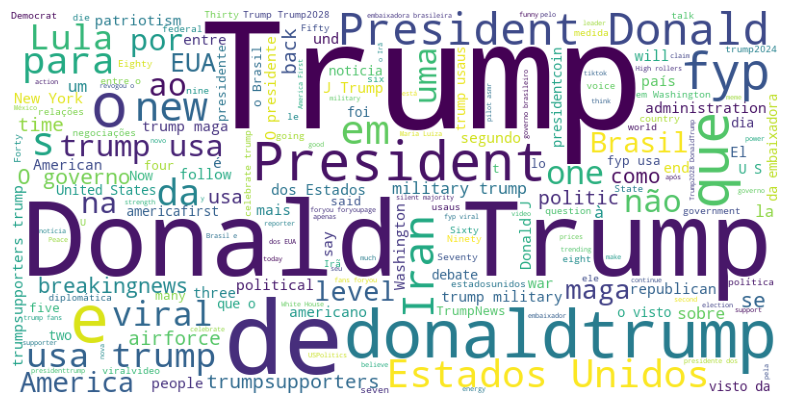

In [6]:
from wordcloud import WordCloud  # importa a classe que gera a nuvem de palavras
import matplotlib.pyplot as plt  # importa o matplotlib, para desenhar a nuvem na tela

textos = []  # cria uma lista vazia para guardar o texto de cada vídeo
for linha in linhas:  # percorre cada item coletado
    textos.append(linha["body"])  # adiciona o texto (legenda) desse item na lista

texto_completo = " ".join(textos)  # junta todos os textos da lista numa única string, separados por espaço

nuvem = WordCloud(width=800, height=400, background_color="white").generate(texto_completo)  # gera a nuvem de palavras a partir do texto completo

plt.figure(figsize=(10, 5))  # cria uma figura (área de desenho) com um tamanho definido
plt.imshow(nuvem)  # desenha a nuvem de palavras dentro da figura
plt.axis("off")  # esconde os eixos numéricos, que não fazem sentido para uma imagem
plt.show()  # exibe a figura na tela

**O que observar:** a biblioteca já remove palavras comuns em inglês (como "the", "and") sozinha, mas não faz isso para português nem para símbolos e emojis dentro do texto. Se a coleta foi em português, é normal ver palavras curtas e pouco informativas dominando a nuvem, isso é assunto para a Aula 20, quando aprendemos a preparar texto antes de analisar.

## 10. Nuvem de palavras das hashtags

O mesmo código serve para as hashtags, só muda a coluna de origem. Como `hashtags` já vem com os valores separados por vírgula, trocamos a vírgula por espaço antes de gerar a nuvem.

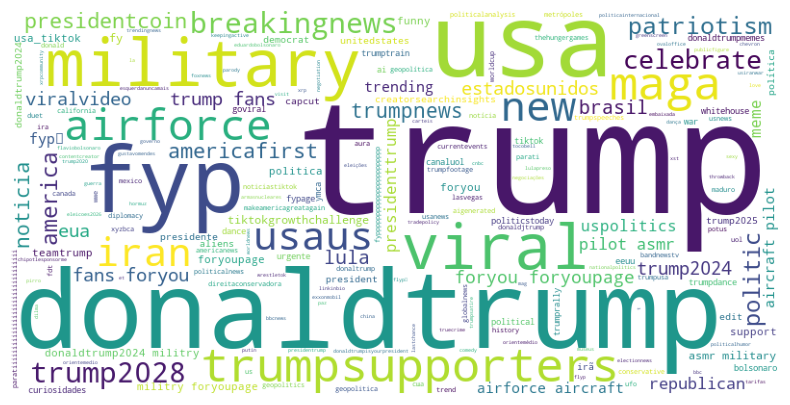

In [7]:
hashtags_textos = []  # cria uma lista vazia para guardar as hashtags de cada item
for linha in linhas:  # percorre cada item coletado
    if linha["hashtags"]:  # só processa se o item tiver alguma hashtag registrada
        hashtags_textos.append(linha["hashtags"].replace(",", " "))  # troca as vírgulas por espaço e adiciona na lista

hashtags_completo = " ".join(hashtags_textos)  # junta as hashtags de todos os itens numa única string

nuvem_hashtags = WordCloud(width=800, height=400, background_color="white").generate(hashtags_completo)  # gera a nuvem de palavras a partir das hashtags

plt.figure(figsize=(10, 5))  # cria uma nova figura com tamanho definido
plt.imshow(nuvem_hashtags)  # desenha a nuvem de hashtags dentro da figura
plt.axis("off")  # esconde os eixos numéricos
plt.show()  # exibe a figura na tela

## 11. Da nuvem ao número: hashtags mais frequentes

A nuvem dá uma impressão geral, mas não diz o número exato de vezes que cada hashtag apareceu. Para isso, contamos com `Counter`, do módulo `collections`, e colocamos o resultado num gráfico de barras.

/var/folders/ns/bgqhy0js3djctln1yxdwt23r0000gn/T/ipykernel_26402/2784856428.py:22: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mateuspestana/Documents/FGV/LabExtracao/2º Período - 2026/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


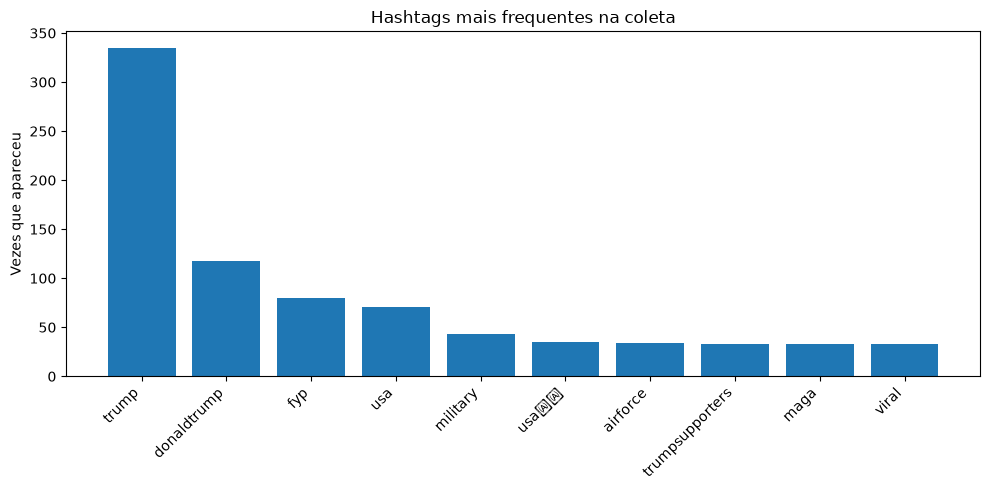

In [8]:
from collections import Counter  # importa o Counter, que conta quantas vezes cada valor aparece

contagem_hashtags = Counter()  # cria um contador vazio
for linha in linhas:  # percorre cada item coletado
    if linha["hashtags"]:  # só processa se o item tiver hashtags
        for hashtag in linha["hashtags"].split(","):  # separa a string de hashtags numa lista, dividindo pela vírgula
            contagem_hashtags[hashtag.strip()] += 1  # remove espaços em volta da hashtag e soma 1 na contagem dela

top_hashtags = contagem_hashtags.most_common(10)  # pega as 10 hashtags que mais apareceram, já ordenadas

nomes = []  # lista para guardar o nome de cada hashtag do top 10
quantidades = []  # lista para guardar a quantidade de vezes que cada uma apareceu
for hashtag, quantidade in top_hashtags:  # percorre os pares (hashtag, quantidade) do top 10
    nomes.append(hashtag)  # adiciona o nome da hashtag na lista de nomes
    quantidades.append(quantidade)  # adiciona a quantidade correspondente na lista de quantidades

plt.figure(figsize=(10, 5))  # cria uma nova figura com tamanho definido
plt.bar(nomes, quantidades)  # desenha um gráfico de barras: uma barra por hashtag, altura = quantidade
plt.xticks(rotation=45, ha="right")  # gira os nomes das hashtags no eixo x, para não sobrepor
plt.ylabel("Vezes que apareceu")  # dá um nome ao eixo y
plt.title("Hashtags mais frequentes na coleta")  # dá um título ao gráfico
plt.tight_layout()  # ajusta os espaçamentos para nada ficar cortado
plt.show()  # exibe o gráfico na tela

## 12. Outras métricas rápidas

Sem sair do que já temos em `linhas`, dá pra responder perguntas simples sobre a coleta: qual vídeo teve mais curtidas, qual a média geral, e como isso varia por autor. Hoje fica só nesse gostinho inicial; a Aula 5 aprofunda métricas de rede social com o Pandas.

In [9]:
curtidas = []  # cria uma lista vazia para guardar o número de curtidas de cada item
for linha in linhas:  # percorre cada item coletado
    curtidas.append(int(linha["likes"]))  # converte o valor de curtidas (texto) para número inteiro e adiciona na lista

maior_curtida = max(curtidas)  # encontra o maior número de curtidas entre todos os itens
for linha in linhas:  # percorre os itens de novo, agora procurando qual bate com esse máximo
    if int(linha["likes"]) == maior_curtida:  # confere se este item tem o número máximo de curtidas
        mais_curtido = linha  # guarda esse item como o mais curtido
        break  # para o laço assim que encontrar o primeiro, não precisa continuar procurando

media_curtidas = sum(curtidas) / len(curtidas)  # soma todas as curtidas e divide pela quantidade de itens

print(f"Vídeo mais curtido: @{mais_curtido['author']}, com {mais_curtido['likes']} curtidas")  # mostra o autor e as curtidas do vídeo mais curtido
print(f"Média de curtidas na coleta: {media_curtidas:.1f}")  # mostra a média de curtidas, com uma casa decimal

Vídeo mais curtido: @teamtrump, com 7000000 curtidas
Média de curtidas na coleta: 36367.4


In [10]:
contagem_autores = Counter()  # cria um contador vazio para os autores
for linha in linhas:  # percorre cada item coletado
    contagem_autores[linha["author"]] += 1  # soma 1 na contagem do autor desse item

autor_mais_frequente, quantidade_videos = contagem_autores.most_common(1)[0]  # pega o autor com mais vídeos e a quantidade dele

curtidas_do_autor = []  # lista para guardar as curtidas só dos vídeos desse autor
for linha in linhas:  # percorre cada item coletado
    if linha["author"] == autor_mais_frequente:  # confere se o item é desse autor específico
        curtidas_do_autor.append(int(linha["likes"]))  # adiciona as curtidas desse item na lista

media_do_autor = sum(curtidas_do_autor) / len(curtidas_do_autor)  # calcula a média de curtidas só desse autor

print(f"Autor com mais vídeos na coleta: @{autor_mais_frequente} ({quantidade_videos} vídeos)")  # mostra quem mais apareceu e quantas vezes
print(f"Média de curtidas desse autor: {media_do_autor:.1f}")  # mostra a média de curtidas desse autor

Autor com mais vídeos na coleta: @realdonaldtrump (10 vídeos)
Média de curtidas desse autor: 267060.0


**O que observar:** repare que "autor com mais vídeos" e "vídeo mais curtido" quase nunca são a mesma pessoa, volume de publicação e engajamento são coisas diferentes. Não confunda um autor aparecer muito na sua coleta com ele ser o mais relevante do tema.

## 13. Baixando as thumbnails

`thumbnail_url` guarda o link direto da imagem de capa de cada vídeo. Para baixar, usamos `urllib.request`, que já vem pronto no Python (sem precisar instalar nada). Ela lembra aquela nossa biblioteca já usada em raspagem, a `requests`. Por ser uma coleta pequena, baixamos as primeiras 20 linhas; ajuste esse número conforme o tamanho da sua coleta.

In [ ]:
import urllib.request  # importa o módulo que baixa arquivos por URL, já incluso no Python
from pathlib import Path  # importa Path, para lidar com caminhos de pasta de forma mais simples

pasta_thumbnails = Path("dados/thumbnails")  # define o caminho da pasta onde as imagens vão ser salvas
pasta_thumbnails.mkdir(parents=True, exist_ok=True)  # cria essa pasta (e as pastas pai, se precisar), sem erro se ela já existir

for linha in linhas[:20]:  # percorre só os 20 primeiros itens coletados
    if linha["thumbnail_url"]:  # só baixa se esse item tiver um link de thumbnail
        destino = pasta_thumbnails / f"{linha['id']}.jpg"  # monta o caminho do arquivo de destino, usando o id do item no nome
        urllib.request.urlretrieve(linha["thumbnail_url"], destino)  # baixa a imagem da URL e salva no destino definido

print(f"Thumbnails salvas em {pasta_thumbnails}")  # avisa onde as imagens foram salvas

## 14. Baixando os vídeos

Mesma lógica, agora com `video_url`. Dois cuidados aqui: nem toda linha tem um `video_url` (por isso o `if` antes de baixar), e o link é temporário, assinado com um prazo de expiração pela própria plataforma. Se você esperar dias para baixar, o link pode não funcionar mais, então baixe logo depois de exportar. Vídeos também são bem mais pesados que thumbnails, por isso baixamos só os 5 primeiros na aula.

In [ ]:
pasta_videos = Path("dados/videos")  # define o caminho da pasta onde os vídeos vão ser salvos
pasta_videos.mkdir(parents=True, exist_ok=True)  # cria essa pasta, sem erro se ela já existir

for linha in linhas[:5]:  # percorre só os 5 primeiros itens coletados
    if linha["video_url"]:  # só baixa se esse item tiver um link de vídeo
        destino = pasta_videos / f"{linha['id']}.mp4"  # monta o caminho do arquivo de destino, usando o id do item no nome
        urllib.request.urlretrieve(linha["video_url"], destino)  # baixa o vídeo da URL e salva no destino definido

print(f"Vídeos salvos em {pasta_videos}")  # avisa onde os vídeos foram salvos

## 15. Quando der errado

- `FileNotFoundError` ao abrir o CSV: confira se o arquivo está em `dados/exportacao.csv` e se o terminal foi aberto na pasta certa.
- Nuvem de palavras vazia ou dando erro: confira se `texto_completo` (ou `hashtags_completo`) não ficou como uma string vazia, o que acontece se a coluna usada não existe no seu export.
- `HTTPError` ou `URLError` ao baixar thumbnail ou vídeo: o link pode ter expirado (comum em `video_url`, depois de algumas horas) ou o item pode não ter mídia associada. Pule esse item e siga para os outros.
- Download muito lento: reduza a fatia (`linhas[:20]`, `linhas[:5]`) para um número menor enquanto testa.

## Prática: faça agora

Abra `exercicios/exercicio-04-coleta-redes.ipynb`. Ele repete o fluxo com um recorte escolhido por você, aprofunda a análise de métricas e termina com a documentação da fonte, do período, da consulta realizada e dos limites éticos da coleta.